In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm  # Using notebook version of tqdm\n

In [2]:
# --- Configuration ---
DATA_DIR = "./"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

BATCH_SIZE = 8
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
IMG_SIZE = 224 # EfficientNetV2 default resolution for faster training

# Check if MPS (Apple Silicon GPU) or CUDA is available
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [3]:
# --- Transforms / Data Augmentation ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
# --- 1. Prepare Dataset & Dataloader ---
print("Loading dataset...")
full_dataset = datasets.ImageFolder(TRAIN_DIR)

targets = full_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    random_state=42,
    stratify=targets
)

class_weights = compute_class_weight("balanced", classes=np.unique(targets), y=targets)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Computed Class Weights (Focal): {class_weights}")

train_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=train_transforms), train_idx)
val_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=val_transforms), val_idx)

# Note: For Jupyter, sometimes num_workers=0 is safer to prevent broken pipe errors
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Loading dataset...
Computed Class Weights (Focal): tensor([0.8843, 2.2323, 0.7036], device='mps:0')


In [5]:
# --- 2. Define Model ---
print("Loading EfficientNetV2-S model...")
weights = models.EfficientNet_V2_S_Weights.DEFAULT
model = models.efficientnet_v2_s(weights=weights)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(full_dataset.classes))
model = model.to(DEVICE)

# --- 3. Loss & Optimizer ---
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Loading EfficientNetV2-S model...


In [6]:
# --- 4. Training Loop ---
best_val_acc = 0.0
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    scheduler.step()
    
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("=> Saved new best model!")


Epoch 1/10


Training:   0%|          | 0/2653 [00:00<?, ?it/s]

Validation:   0%|          | 0/664 [00:00<?, ?it/s]

Train Loss: 0.3023 | Train Acc: 0.8867
Val Loss: 0.1391 | Val Acc: 0.9427
=> Saved new best model!

Epoch 2/10


Training:   0%|          | 0/2653 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/664 [00:00<?, ?it/s]

Train Loss: 0.0257 | Train Acc: 0.9896
Val Loss: 0.2180 | Val Acc: 0.9610

Epoch 10/10


Training:   0%|          | 0/2653 [00:00<?, ?it/s]

Validation:   0%|          | 0/664 [00:00<?, ?it/s]

Train Loss: 0.0185 | Train Acc: 0.9927
Val Loss: 0.2218 | Val Acc: 0.9604


In [7]:
# --- 5. Inference / Generating Submission ---
print("\nRunning Inference on Test Set...")
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.image_files = sorted([f for f in os.listdir(test_dir) if f.endswith(".jpg")], 
                                  key=lambda x: int(os.path.splitext(x)[0]))
        self.transform = transform
        
    def __len__(self):
        return len(self.image_files)
        
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return img_name, image

test_dataset = TestDataset(TEST_DIR, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

predictions = []
with torch.no_grad():
    for img_names, inputs in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = outputs.max(1)
        
        for img_name, pred in zip(img_names, preds):
            img_id = os.path.splitext(img_name)[0]
            predictions.append({"id": img_id, "predicted": pred.item()})
            
submission_df = pd.DataFrame(predictions)
submission_df["id"] = submission_df["id"].astype(int)
submission_df = submission_df.sort_values("id")
submission_df.to_csv("submission_baseline.csv", index=False)
print("Berhasil menyimpan file submission ke submission_baseline.csv!")


Running Inference on Test Set...


Testing:   0%|          | 0/183 [00:00<?, ?it/s]

Berhasil menyimpan file submission ke submission_baseline.csv!


Total salah tebak (Error): 81 gambar


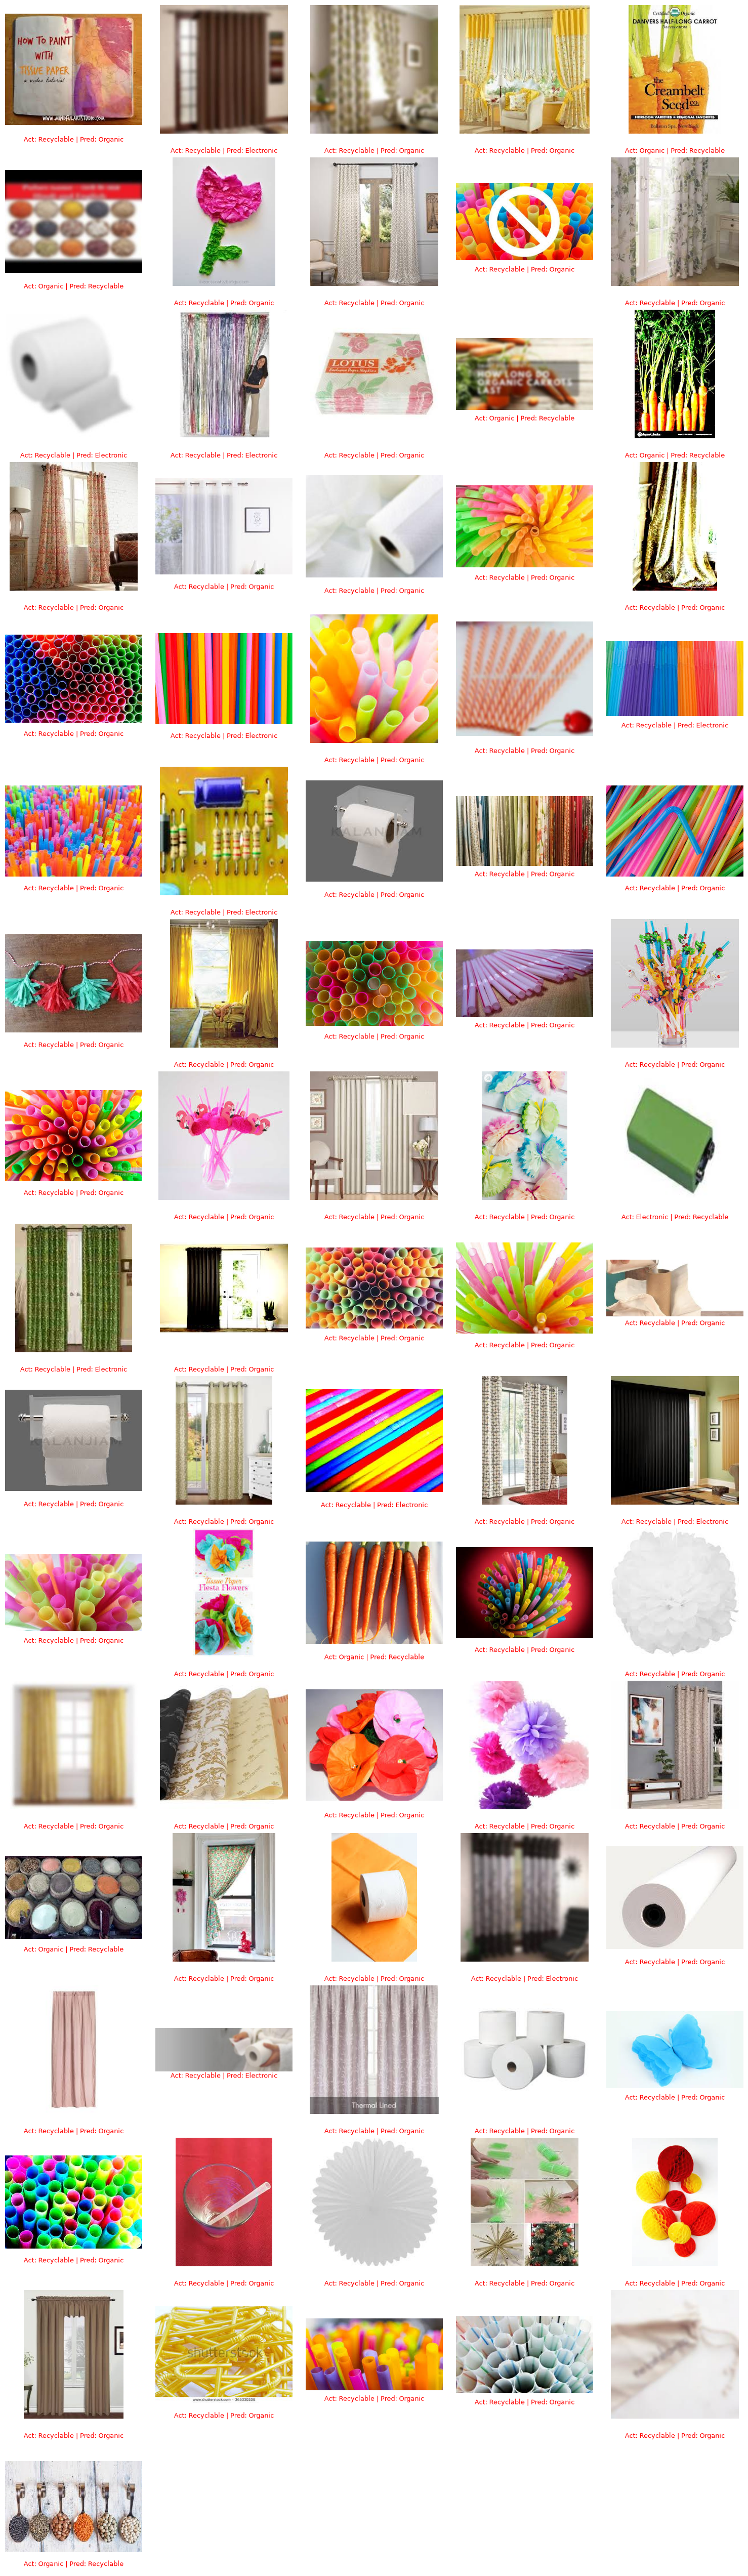

In [13]:
# --- 6. Visualisasi Error di Test Set ---
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
from PIL import Image

# Load Kunci Jawaban & Prediksi
true_df = pd.read_csv("Kunci Jawaban BDC 2026(Kunci Jawaban).csv")
pred_df = pd.read_csv("submission_baseline.csv")

# Pastikan tipe id sama untuk di-merge
true_df["id"] = true_df["id"].astype(int)
pred_df["id"] = pred_df["id"].astype(int)

# Gabungkan data
df = pd.merge(true_df, pred_df, on="id")

# Buat nama file gambar
df["filename"] = df["id"].astype(str) + ".jpg"

# Cari yang salah
salah_df = df[df["Code"] != df["predicted"]]
print(f"Total salah tebak (Error): {len(salah_df)} gambar")

# Mapping label
label_map = {0: "Recyclable", 1: "Electronic", 2: "Organic"}

# Tampilkan SEMUA gambar yang salah
num_show = len(salah_df)
if num_show > 0:
    # Bikin grid dinamis (5 kolom, baris menyesuaikan jumlah error)
    cols = 5
    rows = math.ceil(num_show / cols)
    
    # Tinggi gambar (figsize) kita sesuaikan jumlah baris biar nggak numpuk
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(salah_df.iterrows()):
        img_path = os.path.join(TEST_DIR, row["filename"])
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[i].imshow(img)
            
            actual_name = label_map.get(row["Code"], str(row["Code"]))
            pred_name = label_map.get(row["predicted"], str(row["predicted"]))
            
            # Letakkan teks di BAWAH gambar, ukuran kecil
            axes[i].set_title("") 
            axes[i].text(0.5, -0.15, f"Act: {actual_name} | Pred: {pred_name}", 
                         fontsize=9, color="red", ha="center", transform=axes[i].transAxes)
            axes[i].axis("off")
        else:
            axes[i].text(0.5, 0.5, "Image Not Found", ha="center", va="center")
            axes[i].axis("off")
            
    # Sembunyikan plot kosong kalau ada sisa di baris terakhir
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
        
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada gambar yang salah.")
